<a href="https://colab.research.google.com/github/2003UJAN/Laryngeal-Cancer-Few-Shot-Learning-XAI/blob/main/Laryngeal_Cancer_XAI_LeNet5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install pytorch_metric_learning

In [5]:
!pip install grad-cam

In [6]:
import os
import zipfile
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score
from pytorch_metric_learning import losses
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

In [7]:
zip_path = 'archive.zip'
extract_path = '.'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [8]:
dataset_path = os.path.join(extract_path, 'laryngeal dataset', 'laryngeal dataset')

In [9]:
transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((32, 32)),  # LeNet-5 typically uses 32x32 input images
    transforms.ToTensor()
])

In [10]:
train_data = datasets.ImageFolder(root=os.path.join(dataset_path, 'FOLD 1'), transform=transform)
val_data = datasets.ImageFolder(root=os.path.join(dataset_path, 'FOLD 2'), transform=transform)
test_data = datasets.ImageFolder(root=os.path.join(dataset_path, 'FOLD 3'), transform=transform)

In [11]:
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

In [17]:
class LeNet5(nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, stride=1, padding=2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5, stride=1, padding=0)
        self.conv3 = nn.Conv2d(16, 120, kernel_size=5, stride=1, padding=0)

        self._to_linear = None
        self.convs = nn.Sequential(self.conv1, nn.ReLU(), nn.MaxPool2d(kernel_size=2, stride=2),
                                   self.conv2, nn.ReLU(), nn.MaxPool2d(kernel_size=2, stride=2),
                                   self.conv3, nn.ReLU())
        self._get_output_size()

        self.fc1 = nn.Linear(self._to_linear, 84)
        self.fc2 = nn.Linear(84, 10)
    def _get_output_size(self):
        with torch.no_grad():
            x = torch.zeros(1, 1, 32, 32)
            x = self.convs(x)
            self._to_linear = x.numel()

    def forward(self, x):
        x = self.convs(x)
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [18]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = LeNet5().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [19]:
for epoch in range(40):
    model.train()
    train_loss = 0
    train_acc = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_preds = outputs.argmax(dim=1)
        train_acc += accuracy_score(labels.cpu(), train_preds.cpu())

    model.eval()
    val_loss = 0
    val_acc = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            val_preds = outputs.argmax(dim=1)
            val_acc += accuracy_score(labels.cpu(), val_preds.cpu())

    print(f'Epoch {epoch+1}, Train Loss: {train_loss/len(train_loader)}, Train Accuracy: {train_acc/len(train_loader)}')
    print(f'Epoch {epoch+1}, Validation Loss: {val_loss/len(val_loader)}, Validation Accuracy: {val_acc/len(val_loader)}')

# Test evaluation
model.eval()
test_acc = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        test_preds = outputs.argmax(dim=1)
        test_acc += accuracy_score(labels.cpu(), test_preds.cpu())

print(f'Test Accuracy: {test_acc/len(test_loader)}')

Epoch 1, Train Loss: 1.9550400120871407, Train Accuracy: 0.24032738095238096
Epoch 1, Validation Loss: 1.4933518809931619, Validation Accuracy: 0.26339285714285715
Epoch 2, Train Loss: 1.4398492574691772, Train Accuracy: 0.234375
Epoch 2, Validation Loss: 1.4223733288901192, Validation Accuracy: 0.26339285714285715
Epoch 3, Train Loss: 1.3783791150365556, Train Accuracy: 0.2537202380952381
Epoch 3, Validation Loss: 1.3505379046712602, Validation Accuracy: 0.36830357142857145
Epoch 4, Train Loss: 1.272539598601205, Train Accuracy: 0.44642857142857145
Epoch 4, Validation Loss: 1.2117407960551125, Validation Accuracy: 0.43526785714285715
Epoch 5, Train Loss: 1.049494743347168, Train Accuracy: 0.48958333333333337
Epoch 5, Validation Loss: 1.106608727148601, Validation Accuracy: 0.4724702380952381
Epoch 6, Train Loss: 0.95677079473223, Train Accuracy: 0.5111607142857143
Epoch 6, Validation Loss: 1.247225786958422, Validation Accuracy: 0.3980654761904762
Epoch 7, Train Loss: 0.94344380497932

In [20]:
def generate_gradcam(model, image, target_layer):
    if image.shape[0] != model.conv1.weight.shape[1]:
        image = image.repeat(model.conv1.weight.shape[1], 1, 1)
    cam = GradCAM(model=model, target_layers=[target_layer])
    grayscale_cam = cam(input_tensor=image.unsqueeze(0))[0, :]
    image = image.permute(1, 2, 0).cpu().numpy()
    cam_image = show_cam_on_image(image, grayscale_cam, use_rgb=True)
    return cam_image

In [21]:
test_iter = iter(test_loader)
images, labels = next(test_iter)
image = images[0].to(device)
target_layer = model.conv3
cam_image = generate_gradcam(model, image, target_layer)

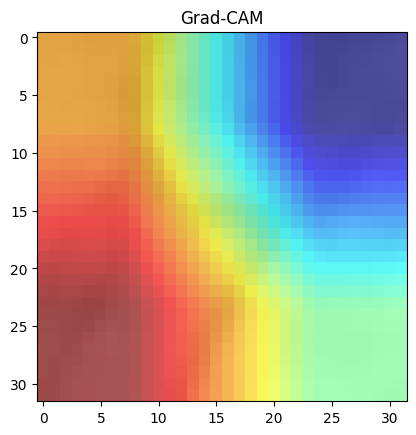

In [22]:
plt.imshow(cam_image)
plt.title('Grad-CAM')
plt.show()